In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [110]:
df_cust = pd.read_csv("dataset/customers.csv")
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [111]:
df_cs = pd.read_csv("dataset/credit_profiles.csv")
df_trans = pd.read_csv("dataset/transactions.csv")

In [112]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [113]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [114]:
df_trans.shape

(500000, 7)

In [115]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [116]:
# Check if any null values in the customers.csv file
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [117]:
# Display top rows of null annual_income values.
df_cust[df_cust.annual_income.isna()].head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married


In [118]:
df_cust[df_cust.annual_income.isna()].shape

(50, 8)

In [119]:
df_cust.annual_income.median()

np.float64(112218.5)

In [120]:
df_cust[df_cust.occupation=="Artist"].annual_income.median()

np.float64(45794.0)

In [121]:
df_cust[df_cust.occupation=="Data Scientist"].annual_income.median()

np.float64(135759.0)

In [122]:
occupation_wise_inc_median = df_cust.groupby("occupation")["annual_income"].median()
occupation_wise_inc_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [123]:
occupation_wise_inc_median["Artist"]

np.float64(45794.0)

In [124]:
def get_median_val(row):
    if pd.isnull(row["annual_income"]):
        return occupation_wise_inc_median[row["occupation"]]
    else:
        return row["annual_income"]

In [125]:
get_median_val({"cust_id": 3232, "occupation": "Artist", "annual_income": None})

np.float64(45794.0)

In [126]:
# Use apply() function to make replace all the null annual_income values with their
# respective median values.

df_cust["annual_income"] = df_cust.apply(
    lambda row: occupation_wise_inc_median[row["occupation"]] if pd.isnull(row["annual_income"]) else row["annual_income"],
    axis=1
)

In [127]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [128]:
# Use the iloc function to check whether null values got replaced with the correct median values

df_cust.iloc[[14, 22, 82]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
22,23,Swara Pawar,Male,19,City,Freelancer,36863.0,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single


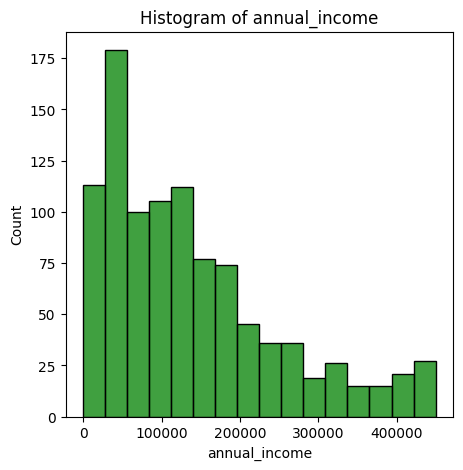

In [129]:
# Plot a histogram for corrected annual_income

plt.figure(figsize=(5,5))
sns.histplot(df_cust['annual_income'], kde=False, color='green', label='Data')
plt.title("Histogram of annual_income")
plt.show()

#### Now we check for outliers and will fix them.

In [130]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [133]:
# If any annual_income < 100, then it is considered an outlier.

df_cust[df_cust.annual_income<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,50.0,Married
262,263,Veer Rathod,Male,53,Suburb,Business Owner,50.0,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,50.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,50.0,Married
340,341,Ridhi Rastogi,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Gauri Gupta,Male,54,City,Consultant,2.0,Married
592,593,Vivaan Pande,Female,32,City,Business Owner,50.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,2.0,Married
686,687,Gauri Nanda,Male,40,City,Business Owner,2.0,Married
696,697,Avani Lalwani,Male,47,City,Consultant,20.0,Married


In [134]:
occupation_wise_inc_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [137]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [140]:
df_cust.at[4, "annual_income"]

np.float64(39406.0)

In [141]:
for index, row in df_cust.iterrows():
    if row['annual_income']<100:
        df_cust.at[index, "annual_income"] = occupation_wise_inc_median[row["occupation"]]

In [142]:
df_cust[df_cust.annual_income<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [143]:
df_cust.loc[[31, 316]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,261191.5,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,58017.0,Married


### Data Visualization: Annual Income

In [145]:
avg_income_occupation = df_cust.groupby("occupation")["annual_income"].mean()
avg_income_occupation

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

In [149]:
avg_income_occupation.index
#avg_income_occupation.values

Index(['Accountant', 'Artist', 'Business Owner', 'Consultant',
       'Data Scientist', 'Freelancer', 'Fullstack Developer'],
      dtype='object', name='occupation')

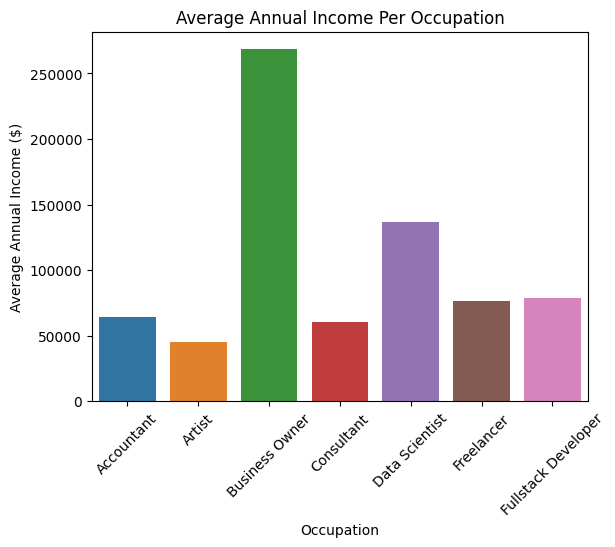

In [155]:
sns.barplot(x=avg_income_occupation.index, y=avg_income_occupation.values, palette="tab10")

plt.xticks(rotation=45)

plt.title("Average Annual Income Per Occupation")
plt.xlabel("Occupation")
plt.ylabel("Average Annual Income ($)")

plt.show()

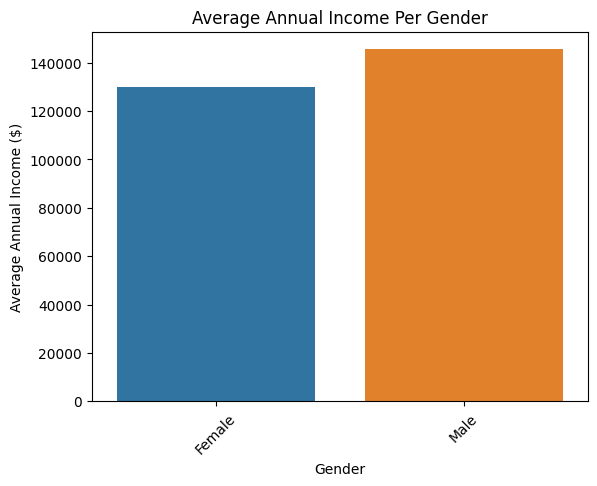

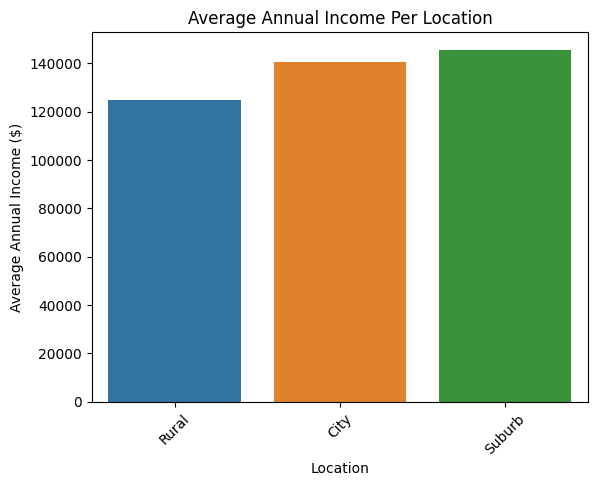

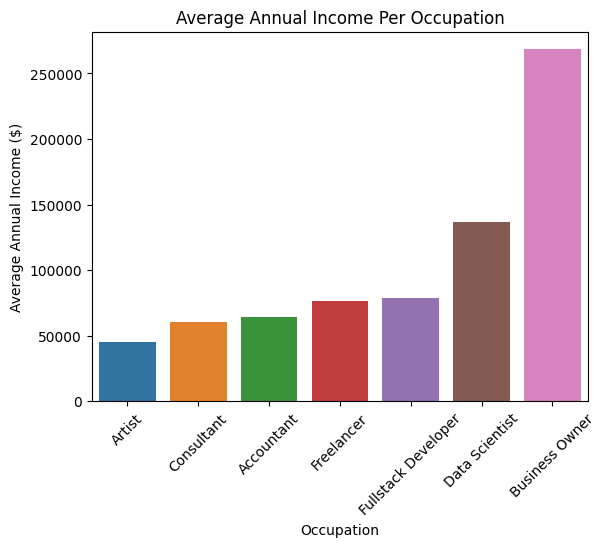

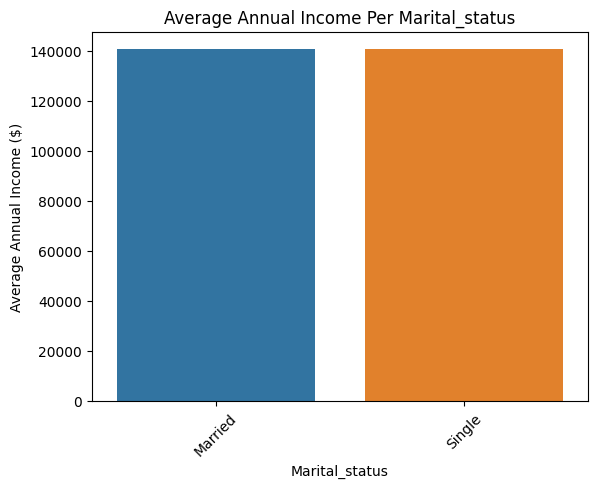

In [156]:
categorial_columns = ['gender', 'location', 'occupation', 'marital_status']

for col in categorial_columns:
    avg_income_per_group = df_cust.groupby(col)['annual_income'].mean().sort_values()
    
    sns.barplot(x=avg_income_per_group.index, y=avg_income_per_group.values, palette="tab10")
    plt.xticks(rotation=45)

    plt.title(f"Average Annual Income Per {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Average Annual Income ($)")
    
    plt.show()

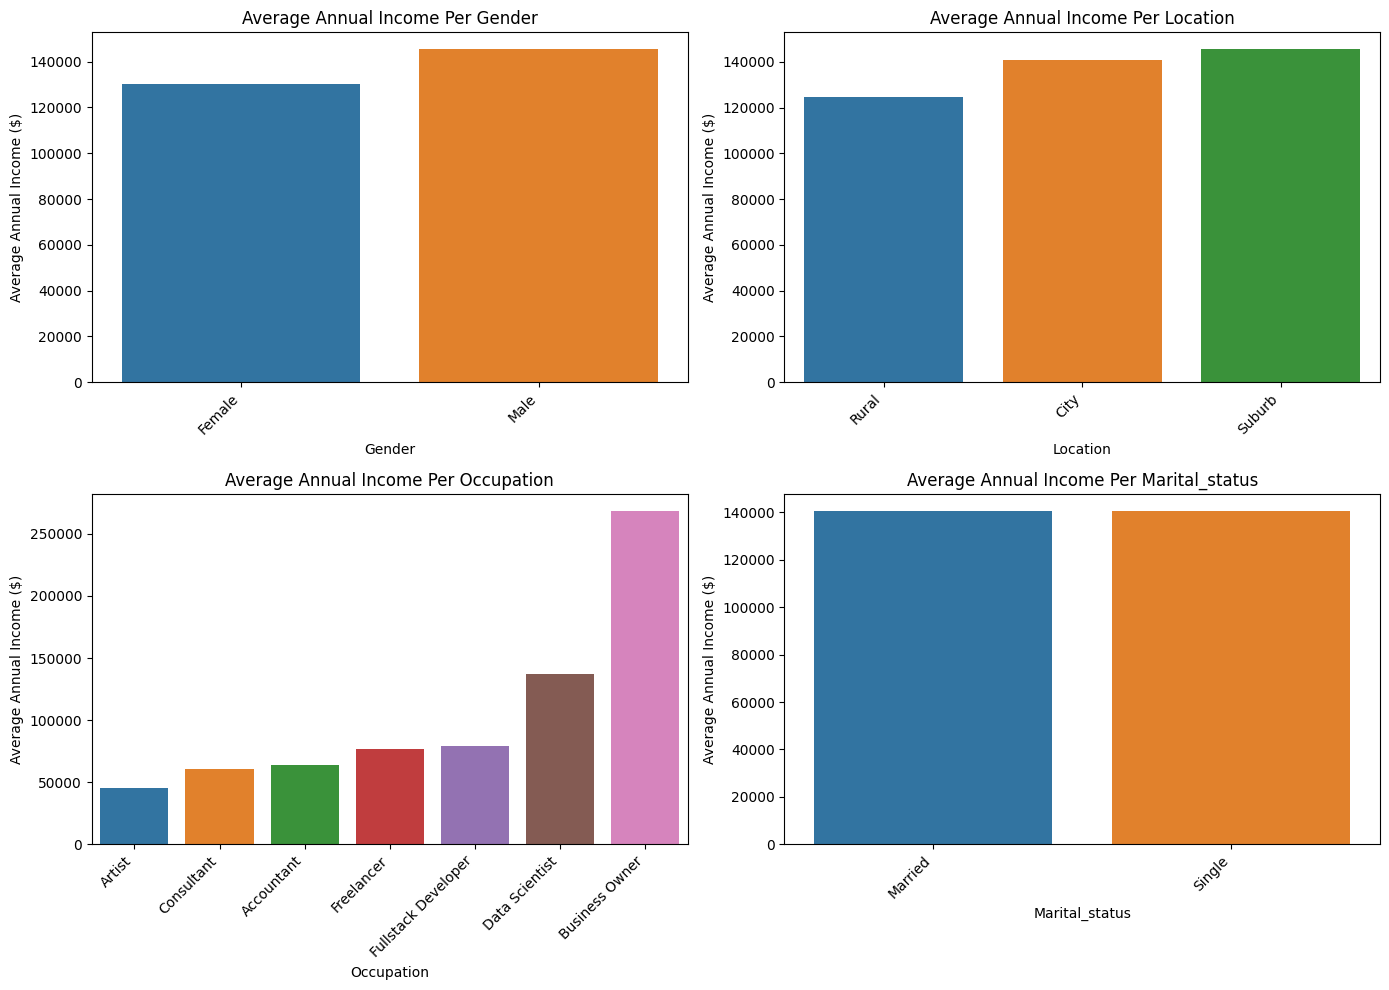

In [158]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

categorical_columns = ['gender', 'location', 'occupation', 'marital_status']

for i, col in enumerate(categorical_columns):
    avg_income_per_group = df_cust.groupby(col)['annual_income'].mean().sort_values()
    
    sns.barplot(x=avg_income_per_group.index, y=avg_income_per_group.values, 
                palette="tab10", ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_title(f"Average Annual Income Per {col.capitalize()}")
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Average Annual Income ($)")

plt.tight_layout()
plt.show()

#### Treat Outliers in Age Column

In [178]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
age_outlier       0
dtype: int64

In [159]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,140483.548500
std,288.819436,15.666155,110463.002934
min,1.000000,1.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,46.000000,195514.250000
max,1000.000000,135.000000,449346.000000


(20, 9)

In [163]:
df_cust.columns

Index(['cust_id', 'name', 'gender', 'age', 'location', 'occupation',
       'annual_income', 'marital_status'],
      dtype='object')

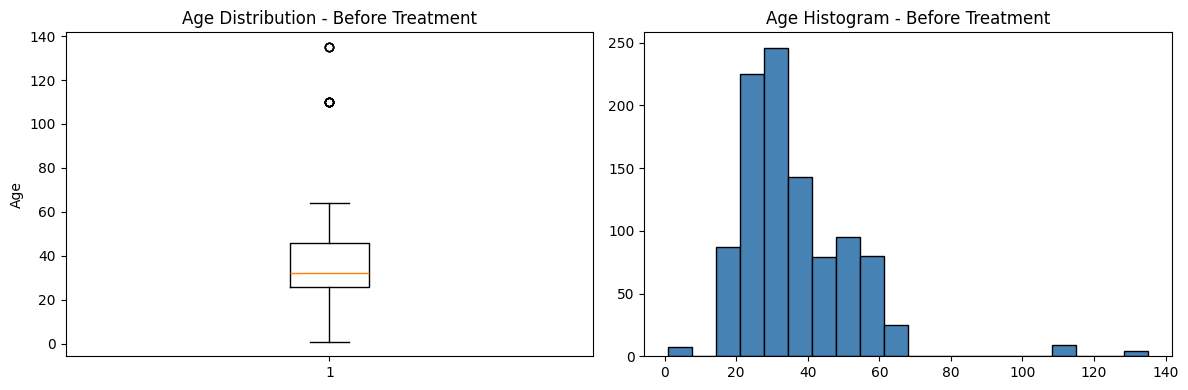

In [164]:
# Step 1: Visualize outliers first
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_cust['age'].dropna())
axes[0].set_title("Age Distribution - Before Treatment")
axes[0].set_ylabel("Age")
axes[1].hist(df_cust['age'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[1].set_title("Age Histogram - Before Treatment")
plt.tight_layout()
plt.show()

In [183]:
outliers = df_cust[(df_cust.age<15) | (df_cust.age>80)]
outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_outlier
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married,True
41,42,Manya Thakur,Male,110,City,Artist,7621.0,Married,True
165,166,Swara Mehtani,Female,1,City,Freelancer,39721.0,Single,True
174,175,Sneha Jaiswal,Male,110,City,Freelancer,23723.0,Married,True
222,223,Aaryan Bajaj,Male,110,Suburb,Freelancer,210987.0,Married,True
277,278,Amaira Dewan,Male,110,City,Consultant,96522.0,Single,True
295,296,Veer Anand,Male,1,Rural,Accountant,55254.0,Married,True
325,326,Yash Chatterjee,Male,110,City,Accountant,61021.0,Single,True
610,611,Advait Mangal,Male,135,Rural,Business Owner,444776.0,Married,True
692,693,Aarohi Dubey,Male,1,City,Business Owner,83045.0,Married,True


In [165]:
# Step 2: Flag outliers (valid age: 15–80)
df_cust['age_outlier'] = ~df_cust['age'].between(15, 80)
print(f"Total outliers detected: {df_cust['age_outlier'].sum()}")

Total outliers detected: 20


In [181]:
occupation_median_age = (df_cust[df_cust['age'].between(15, 80)]
                         .groupby('occupation')['age']
                         .median())
occupation_median_age

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [184]:
median_age_per_occupation = df_cust.groupby("occupation")["age"].median()
median_age_per_occupation

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [186]:
for index, row in outliers.iterrows():
    df_cust.at[index, "age"] = median_age_per_occupation[row["occupation"]]

In [187]:
df_cust[(df_cust.age<15) | (df_cust.age>80)]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_outlier


In [188]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,35.541500,140483.548500
std,288.819436,12.276634,110463.002934
min,1.000000,18.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,44.250000,195514.250000
max,1000.000000,64.000000,449346.000000


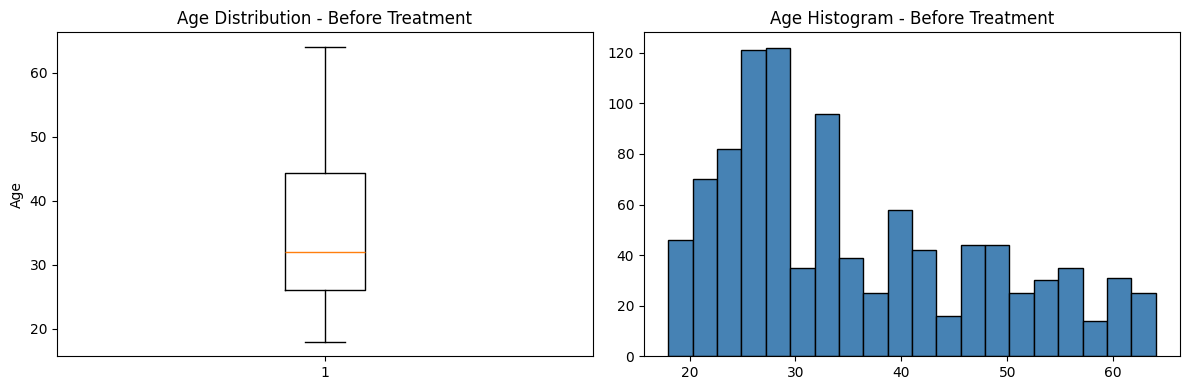

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_cust['age'].dropna())
axes[0].set_title("Age Distribution - Before Treatment")
axes[0].set_ylabel("Age")
axes[1].hist(df_cust['age'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[1].set_title("Age Histogram - Before Treatment")
plt.tight_layout()
plt.show()

In [190]:
df_cust['age_group'] = pd.cut(
    df_cust['age'],
    bins=[17, 25, 48, 65],
    labels=['18-25', '26-48', '49-65']
)

In [191]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_outlier,age_group
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,True,49-65
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,False,26-48
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,False,18-25
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,False,18-25
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,False,26-48


In [195]:
age_group_counts = df_cust.age_group.value_counts(normalize=True)*100
age_group_counts

age_group
26-48    56.7
18-25    24.6
49-65    18.7
Name: proportion, dtype: float64

In [196]:
type(age_group_counts)

pandas.core.series.Series

In [200]:
age_group_counts.index

CategoricalIndex(['26-48', '18-25', '49-65'], categories=['18-25', '26-48', '49-65'], ordered=True, dtype='category', name='age_group')

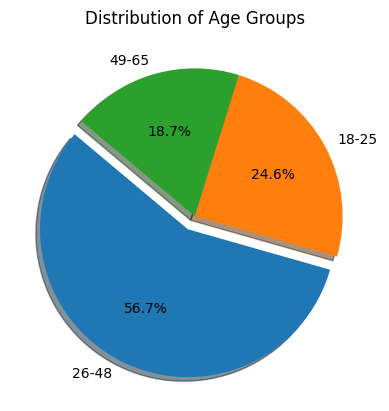

In [210]:
plt.pie(age_group_counts, 
        labels=age_group_counts.index, 
        autopct='%1.1f%%', 
        shadow=True,
        explode=(0.1,0,0),
        startangle=140
    )

plt.title('Distribution of Age Groups')
plt.show()

In [211]:
df_cust.location.value_counts()

location
City      683
Suburb    232
Rural      85
Name: count, dtype: int64

In [212]:
df_cust.gender.value_counts()

gender
Male      674
Female    326
Name: count, dtype: int64

In [218]:
# it will give you pandas series type
df_cust.groupby(['location', 'gender']).size()

location  gender
City      Female    226
          Male      457
Rural     Female     26
          Male       59
Suburb    Female     74
          Male      158
dtype: int64

In [220]:
# convert the above series into dataframe using unstack() function
customer_location_gender = df_cust.groupby(['location', 'gender']).size().unstack()
customer_location_gender

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


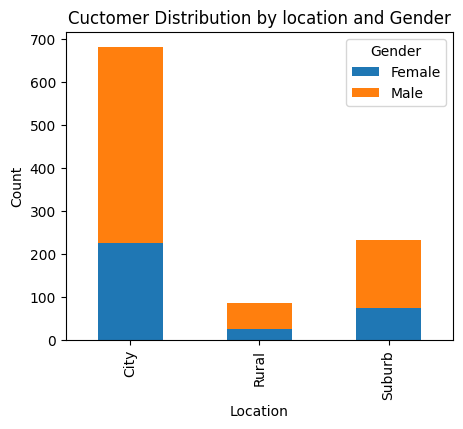

In [225]:
customer_location_gender.plot(kind='bar', stacked=True, figsize=(5,4))
plt.title('Cuctomer Distribution by location and Gender')
plt.legend(title='Gender')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()